![](https://raw.githubusercontent.com/kerryback/workshop_python/main/images/mcnair.jpg)

---

### JGSB Python Workshop Part 12: Simulation

**Authored by Kerry Back, 09/06/2025**

---



### Overview

We can generate random variables in Python with either `np.random` or `scipy.stats`.  Both produce numpy arrays.  

First, we need to discuss numpy arrays.  They are similar to lists of numbers, but they can be multidimensional and they are designed to facilitate doing arithmetic on entire arrays or slices of arrays.  

Pandas is built on numpy.  We did pandas first, because you will probably work more with pandas than with numpy.  But now, finally, we will cover a bit of numpy.

### Numpy arrays

The following cell shows how to create and slice numpy arrays.

In [1]:
import numpy as np 

# create a 1-dimensional array
arr_1d = np.array([1.1, 1.4, 2.6])
print('\n 1-Dimensional Array')
print(arr_1d)

# create a 2-dimensional array
arr_2d = np.array([
    [1.1, 1.4, 2.6],
    [-3.2, 5.603, 4]
])
print('\n2-Dimensional Array')
print(arr_2d)

# slice a 1-dimensional array (like slicing a list)
print('\nExtract a single element from a 1d array')
print(arr_1d[1])
print('\nExtract a range from a 1d array')
print(arr_1d[:2])

# slice a 2-dimensional array - index is [row, column]
print('\nExtract a single element from a 2d array')
print(arr_2d[0, 1])
print('\nExtract a range from a 2d array')
print(arr_2d[:, :2])


 1-Dimensional Array
[1.1 1.4 2.6]

2-Dimensional Array
[[ 1.1    1.4    2.6  ]
 [-3.2    5.603  4.   ]]

Extract a single element from a 1d array
1.4

Extract a range from a 1d array
[1.1 1.4]

Extract a single element from a 2d array
1.4

Extract a range from a 2d array
[[ 1.1    1.4  ]
 [-3.2    5.603]]


### Array addition and multiplication

- When arrays are added, each element of one array is added to the corresponding element of the other array.
- When arrays are multiplied, each element of one array is multiplied by the corresponding element of the other array.
- Same for subtracting and dividing.

**Broadcasting:**  

- Arrays of different sizes can sometimes be added together or multiplied together, etc.  
- Numpy will do this when one array is larger and its shape is the same as stacking multiple versions of the smaller array side by side or on top of each other.  
- When this is true, numpy expands the smaller array by copying it into the same shape as the larger array and then doing the addition or multiplication or whatever.
- An important special case is adding a single number to an array or multiplying an array by a single number.  In this case, the operation is applied to each element of the array.

In [2]:
# array addition (sum element by element)
arr_1d_second = np.array([7, 4.3, 1.1])
print('\nAdd arrays')
print(f'array 1: {arr_1d}')
print(f'array 2: {arr_1d_second}')
print(f'sum of two arrays: {arr_1d + arr_1d_second}')

# array multiplication (multiply element by element)
print('\nMultiply arrays')
print(f'array 1: {arr_1d}')
print(f'array 2: {arr_1d_second}')
print(f'product of two arrays: {arr_1d * arr_1d_second}')

# simple broadcasting example
print('\nBroadcast a single number over an array')
print(f'original array:\n{arr_2d}')
print(f'original array * 2:\n{2*arr_2d}')


Add arrays
array 1: [1.1 1.4 2.6]
array 2: [7.  4.3 1.1]
sum of two arrays: [8.1 5.7 3.7]

Multiply arrays
array 1: [1.1 1.4 2.6]
array 2: [7.  4.3 1.1]
product of two arrays: [7.7  6.02 2.86]

Broadcast a single number over an array
original array:
[[ 1.1    1.4    2.6  ]
 [-3.2    5.603  4.   ]]
original array * 2:
[[ 2.2    2.8    5.2  ]
 [-6.4   11.206  8.   ]]


### Array methods

Arrays have some of the same methods as pandas DataFrames and Series.  We only give a couple of examples.

In [3]:
# sum method
print('\nArray sum method')
print(f'array: {arr_1d}')
print(f'sum method produces: {arr_1d.sum()}')

# standard deviation method
print('\nArray std (standard deviation) method')
print(f'array: {arr_1d}')
print(f'std method produces: {arr_1d.std()}')


Array sum method
array: [1.1 1.4 2.6]
sum method produces: 5.1

Array std (standard deviation) method
array: [1.1 1.4 2.6]
std method produces: 0.6480740698407861


### Rolling Dice and Flipping Coins

Now, we are ready to get to simulation.  We'll use `np.random`.  This module can generate many different types of random variables, including normally distributed random variables.  We start with a simple example of random integers, using `np.random.randint`.


- `randint` generates a random integer in a range that starts with the lower bound specified and goes up to but not including the upper bound.
- We specify how many random numbers we want.
- Setting a seed for random number generation is done so that we will all get the same "random" numbers.  In much online code and in much AI generated code, you will see the seed set to 42.  Ask Gemini why if you are curious.

=== DICE ROLLING SIMULATION ===
First 10 rolls: [4 5 3 5 5 2 3 3 3 5]


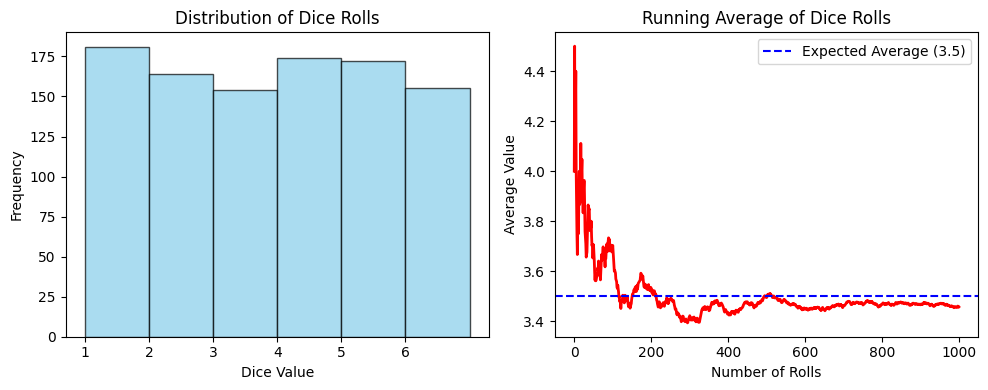

In [8]:
# Set up our environment
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducible results
np.random.seed(42)

print("=== DICE ROLLING SIMULATION ===")

# Roll a six-sided die 1000 times
num_rolls = 1000
dice_rolls = np.random.randint(1, 7, num_rolls)

# Examine the first 10 rolls
print(f"First 10 rolls: {dice_rolls[:10]}")

# Visualize the results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(dice_rolls, bins=range(1, 8), alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Dice Rolls')
plt.xlabel('Dice Value')
plt.ylabel('Frequency')
plt.xticks(range(1, 7))

plt.subplot(1, 2, 2)
# Show running average
running_average = np.cumsum(dice_rolls) / np.arange(1, num_rolls + 1)
plt.plot(running_average, color='red', linewidth=2)
plt.axhline(y=3.5, color='blue', linestyle='--', label='Expected Average (3.5)')
plt.title('Running Average of Dice Rolls')
plt.xlabel('Number of Rolls')
plt.ylabel('Average Value')
plt.legend()

plt.tight_layout()
plt.show()

### Exercise 1: Simulate Coin Flips

In [6]:
# Exercise 1: Simulate coin flips
# Flip a coin 100 times and count heads vs tails
# Create a variable 'coin_flips' with the results (1 = heads, 0 = tails)


# Check your work
num_heads = np.sum(coin_flips)
num_tails = len(coin_flips) - num_heads
print(f"Results: {num_heads} heads, {num_tails} tails")
print(f"Percentage heads: {num_heads/len(coin_flips)*100:.1f}%")
assert len(coin_flips) == 100, "Should have 100 flips"
assert all(flip in [0, 1] for flip in coin_flips), "Flips should be 0 or 1"
print("Great job! You simulated coin flips.")

NameError: name 'coin_flips' is not defined

### Normal Distibutions

Our next example involves generating normally distributed random variables in a somewhat more complex business-type setting.  There are three steps in this example.

**A.**  Create a function for simulating total annual sales given some assumptions.
**B.** Run the function 1,000 times and compile a list of total sales for each of the 1,000 simulated years.
**C.** Summarize the results, including visualizations.

Obviously, we don't plan to operate the business for 1,000 years.  We just want to know the distribution of possible sales for next year.  It is somewhat complicated to calculate this distribution directly, because of the variation in sales across months.  So, we simulate 1,000 possible outcomes for next year's sales.

=== MONTHLY SALES SIMULATION ===
Running 1000 simulations...

=== ANALYSIS OF 1000 SIMULATED YEARS ===
Average annual sales: $314,614
Minimum annual sales: $256,747
Maximum annual sales: $373,673

Planning scenarios:
Pessimistic (10th percentile): $292,487
Optimistic (90th percentile): $336,429


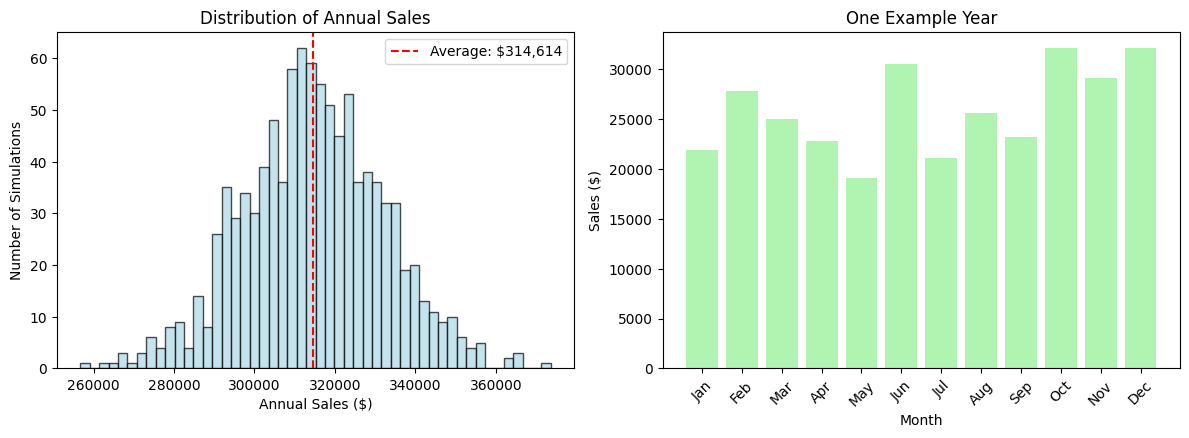


Probability of meeting $300,000 target: 79.8%


In [ ]:
print("=== MONTHLY SALES SIMULATION ===")

# A small business wants to forecast next year's sales
# They know:
# - Average monthly sales: $25,000
# - Sales vary by about 20% (some months higher, some lower)
# - Sales are typically higher in December (holiday season)

base_monthly_sales = 25000
monthly_variation = 0.20  # 20% variation

# Seasonal factors (multipliers for each month)
seasonal_factors = [
    0.9,   # January (post-holiday slump)
    0.9,   # February
    1.0,   # March
    1.0,   # April
    1.1,   # May
    1.1,   # June
    1.0,   # July
    1.0,   # August
    1.0,   # September
    1.1,   # October
    1.2,   # November
    1.3    # December (holiday boost)
]

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Part A: Create a function to simulate one year of sales
def simulate_one_year():
    monthly_sales = []
    for month in range(12):
        # Base sales for this month with seasonal adjustment
        expected_sales = base_monthly_sales * seasonal_factors[month]
        
        # Add random variation (normal distribution)
        actual_sales = np.random.normal(expected_sales, expected_sales * monthly_variation)
        
        # Make sure sales aren't negative
        actual_sales = max(actual_sales, 0)
        monthly_sales.append(actual_sales)
    
    return monthly_sales

# Part B. Simulate 1,000 possible years and compile a list of total sales each year.
num_simulations = 1000
all_annual_totals = []

print(f"Running {num_simulations} simulations...")
for sim in range(num_simulations):
    year_sales = simulate_one_year()
    all_annual_totals.append(sum(year_sales))

all_annual_totals = np.array(all_annual_totals)

# Part C.  Analyze results
print(f"\n=== ANALYSIS OF {num_simulations} SIMULATED YEARS ===")
print(f"Average annual sales: ${all_annual_totals.mean():,.0f}")
print(f"Minimum annual sales: ${all_annual_totals.min():,.0f}")
print(f"Maximum annual sales: ${all_annual_totals.max():,.0f}")

# Calculate percentiles (useful for planning)
percentile_10 = np.percentile(all_annual_totals, 10)
percentile_90 = np.percentile(all_annual_totals, 90)

print(f"\nPlanning scenarios:")
print(f"Pessimistic (10th percentile): ${percentile_10:,.0f}")
print(f"Optimistic (90th percentile): ${percentile_90:,.0f}")

# Visualize the results
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.hist(all_annual_totals, bins=50, alpha=0.7, color='lightblue', edgecolor='black')
plt.axvline(all_annual_totals.mean(), color='red', linestyle='--', 
           label=f'Average: ${all_annual_totals.mean():,.0f}')
plt.title('Distribution of Annual Sales')
plt.xlabel('Annual Sales ($)')
plt.ylabel('Number of Simulations')
plt.legend()

plt.subplot(2, 2, 2)
# Show one example year
example_year = simulate_one_year()
plt.bar(month_names, example_year, color='lightgreen', alpha=0.7)
plt.title('One Example Year')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Business insights
target_sales = 300000
prob_meeting_target = np.mean(all_annual_totals >= target_sales) * 100
print(f"\nProbability of meeting ${target_sales:,} target: {prob_meeting_target:.1f}%")

### Exercise 2: Retirement Planning 

In this exercise, you'll simulate retirement savings growth and withdrawal scenarios to help plan for financial security.  We'll do it in three parts like the previous example.  First, here are our assumptions.

In [ ]:
# Run this cell

# Scenario: Complete lifetime financial planning
# Phase 1 - ACCUMULATION: Save for retirement while working
# Phase 2 - RETIREMENT: Withdraw funds for living expenses
# 
#  Assumptions:
# - Starting savings: $50,000
# - Annual contribution during working years: $25,000
# - Working period: 30 years
# - Annual withdrawal in retirement: $100,000 (adjusted for inflation)
# - Retirement period: 25 years
# - Do everything in real terms (today's dollars)
# - Investment returns vary each year (historical average ~7%, but with volatility)
# - Inflation averages 3% per year but varies

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# PART 1: Create a function to simulate one lifetime
def simulate_one_lifetime():
    """
    Simulate a complete lifetime: accumulation phase followed by retirement phase.
    Returns the balance at retirement and the ending balance after retirement.
    """
    # Initial parameters
    initial_savings = 50000      # Starting balance
    annual_contribution = 25000  # Annual savings during working years
    working_years = 30           # Years until retirement
    retirement_years = 25        # Years in retirement
    base_withdrawal = 100000     # Annual withdrawal in retirement (year 1)
    
    # Return parameters
    avg_return = 0.07           # Average annual return (7%)
    return_volatility = 0.15    # Standard deviation of returns

### Part A

Create a function that simulates one lifetime using the above parameters.  The function should contain two loops, the first looping over working years and the second looping over retirement years.  Ask Gemini if you need assistance creating this function.

### Part B

Run the function 1,000 times and compile a list of the balance at the end of the retirement period for each simulated lifetime.  Again, ask Gemini if you need assistance.

### Part C

Calculate the mean, median, standard deviation and percentiles (10%, 25%, ...) of the 1,000 simulated ending balances. Create appropriate visualizations.  Again, ask Gemini if you need assistance.

**Hint 1:** To calculate the statistics, you can use

```python
ser = pd.Series(list_of_ending_balances)
```

and then use pandas Series methods, like `ser.mean()`, `ser.median()`, `ser.std()`, and `ser.quantile(0.1)`.  This is an alternative to the numpy functions used in the previous example.

**Hint 2:**  To generate a quick histogram, you can use `ser.hist()`.  Or you can fine tune it with options like the following.

```python
ser = ser / 1000
ser.hist(bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Ending Balances')
plt.xlabel('Ending Balance')
plt.ylabel('Frequency')
plt.show()
```